In [2]:
#New Notebook
#Runtime → Change runtime type → Hardware accelerator → GPU → Save
#to check the GPU is set in the runtime environment
!nvidia-smi

Mon Apr 27 17:48:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             14W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
#New Notebook
#Runtime → Change runtime type → Hardware accelerator → GPU → Save
#to check the GPU is set in the runtime environment
!nvidia-smi

Mon Apr 20 16:40:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
#install required libraries
!pip install kaggle opencv-python-headless scikit-learn joblib matplotlib seaborn pillow numpy pandas

In [ ]:
#kaggle API - create legacy API -- files kaggle.json
from google.colab import files
uploaded = files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print("Kaggle API ready!")

Saving kaggle.json to kaggle.json
Kaggle API ready!


In [ ]:
#To verify
!kaggle datasets list

ref                                                          title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                               Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000           7649        183                1  
nalisha/job-salary-prediction-dataset                        Job Salary Prediction Dataset                          3144815  2026-03-16 19:54:33.843000          13786        309                1  
meruvakodandasuraj/youtube-trending-videos-20202026          YouTube Trending Videos 2020–2026                       843930  2026-04-13 11:10:04.770000            579         27                1  
mubashirsidiki/

In [ ]:
#dowload face dataset  - DOWNLOAD, UPZIP, DATASET
!kaggle datasets download -d ciplab/real-and-fake-face-detection
!unzip -q real-and-fake-face-detection.zip -d /content/dataset/
!ls /content/dataset/

Dataset URL: https://www.kaggle.com/datasets/ciplab/real-and-fake-face-detection
License(s): CC-BY-NC-SA-4.0
100% 431M/431M [00:30<00:00, 14.9MB/s]

real_and_fake_face  real_and_fake_face_detection


In [ ]:
import os, glob

# Check what's actually inside training_fake
print("=== training_fake contents ===")
base = '/content/dataset/real_and_fake_face/training_fake'
for item in os.listdir(base):
    path = os.path.join(base, item)
    if os.path.isdir(path):
        count = len(glob.glob(path + '/*.jpg'))
        print(f"  {item}/  →  {count} images")
    else:
        print(f"  {item}")

print("\n=== training_real count ===")
real_count = len(glob.glob('/content/dataset/real_and_fake_face/training_real/*.jpg'))
print(f"  training_real/  →  {real_count} images")

=== training_fake contents ===
  hard_157_1111.jpg
  hard_50_1101.jpg
  hard_83_1111.jpg
  mid_294_1110.jpg
  mid_271_1111.jpg
  mid_156_1111.jpg
  easy_110_0001.jpg
  mid_290_1100.jpg
  easy_182_0100.jpg
  easy_130_1101.jpg
  mid_114_1110.jpg
  hard_119_1100.jpg
  mid_207_1111.jpg
  easy_162_0001.jpg
  hard_210_1100.jpg
  hard_22_1111.jpg
  mid_233_1111.jpg
  hard_221_0101.jpg
  hard_138_1101.jpg
  easy_123_0100.jpg
  easy_149_1001.jpg
  hard_85_1111.jpg
  easy_82_0001.jpg
  hard_127_0011.jpg
  mid_351_0110.jpg
  hard_211_0110.jpg
  hard_154_1100.jpg
  easy_72_1111.jpg
  easy_1_1110.jpg
  hard_44_1111.jpg
  easy_71_1100.jpg
  mid_144_1110.jpg
  mid_398_0011.jpg
  mid_106_0001.jpg
  mid_371_0011.jpg
  easy_205_1110.jpg
  mid_126_1110.jpg
  mid_412_0011.jpg
  mid_139_1111.jpg
  mid_119_1111.jpg
  mid_349_1111.jpg
  hard_151_0101.jpg
  easy_231_1011.jpg
  mid_59_1111.jpg
  hard_156_1111.jpg
  mid_480_1111.jpg
  mid_127_0011.jpg
  mid_173_1110.jpg
  easy_152_0011.jpg
  mid_363_1101.jpg
  

In [ ]:
#Create project folder structure
import os

folders = [
    '/content/project/models',
    '/content/project/results',
]
for f in folders:
    os.makedirs(f, exist_ok=True)

print("Folder structure created:")
for f in folders:
    print(f"  {f}")

Folder structure created:
  /content/project/models
  /content/project/results


In [ ]:
#Module 1 - Organize dataset (original vs morphed) (DATASET --- PROJECT DATASET - COPY)
import shutil, glob, os

os.makedirs('/content/project/dataset/original', exist_ok=True)
os.makedirs('/content/project/dataset/morphed',  exist_ok=True)

# Real images
real_imgs = sorted(glob.glob(
    '/content/dataset/real_and_fake_face/training_real/*.jpg'))
for i, src in enumerate(real_imgs):
    shutil.copy(src, f'/content/project/dataset/original/orig_{i:04d}.jpg')

# Fake images — use ** to find files in ALL subdirectories
fake_imgs = sorted(glob.glob(
    '/content/dataset/real_and_fake_face/training_fake/**/*.jpg',
    recursive=True))
for i, src in enumerate(fake_imgs):
    shutil.copy(src, f'/content/project/dataset/morphed/morph_{i:04d}.jpg')

orig_count  = len(os.listdir('/content/project/dataset/original'))
morph_count = len(os.listdir('/content/project/dataset/morphed'))
print(f"Original images : {orig_count}")
print(f"Morphed  images : {morph_count}")
print(f"Total           : {orig_count + morph_count}")

Original images : 1081
Morphed  images : 960
Total           : 2041


In [ ]:
#Module 2: Preprocessing
import cv2
import numpy as np

IMG_SIZE = 64

def load_images(folder, label):
    X, y = [], []
    # sorted() ensures same order every run
    for fname in sorted(os.listdir(folder)):
        if not fname.lower().endswith(('.jpg','.jpeg','.png')):
            continue
        img = cv2.imread(os.path.join(folder, fname))
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = img.flatten()
        img = img / 255.0
        X.append(img)
        y.append(label)
    return np.array(X), np.array(y)

print("Loading original images...")
X_orig, y_orig = load_images('/content/project/dataset/original', 0)
print("Loading morphed images...")
X_morph, y_morph = load_images('/content/project/dataset/morphed', 1)

X = np.vstack([X_orig, X_morph])
y = np.concatenate([y_orig, y_morph])

np.save('/content/project/dataset/X.npy', X)
np.save('/content/project/dataset/y.npy', y)

print(f"\nDataset shape      : {X.shape}")
print(f"Label 0 (Original) : {np.sum(y==0)}")
print(f"Label 1 (Morphed)  : {np.sum(y==1)}")

Loading original images...
Loading morphed images...

Dataset shape      : (2041, 4096)
Label 0 (Original) : 1081
Label 1 (Morphed)  : 960


Before PCA: 4096 features
After PCA : 150 features
Variance retained: 89.77%


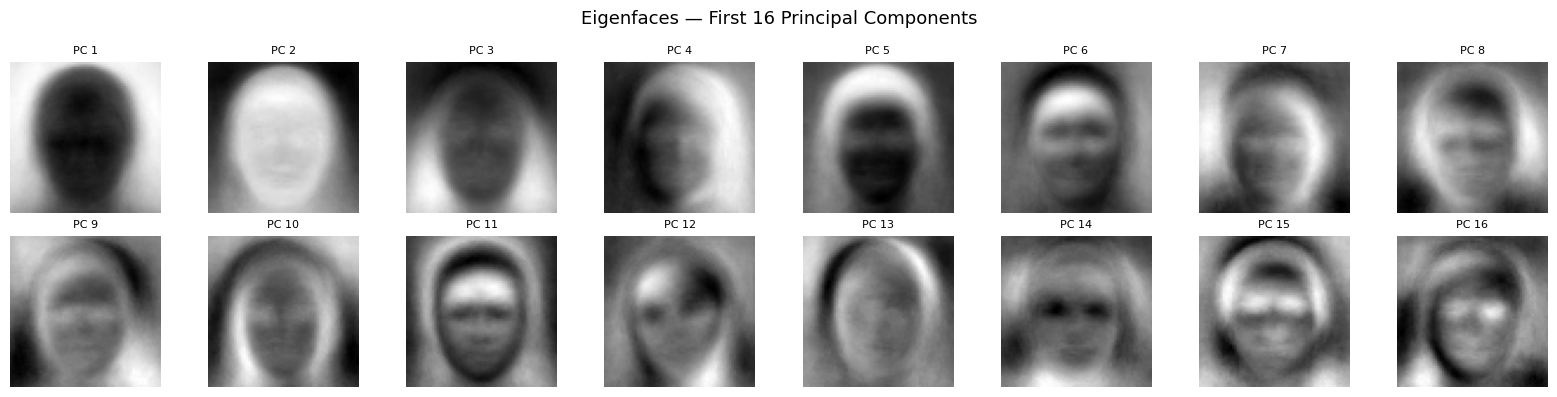

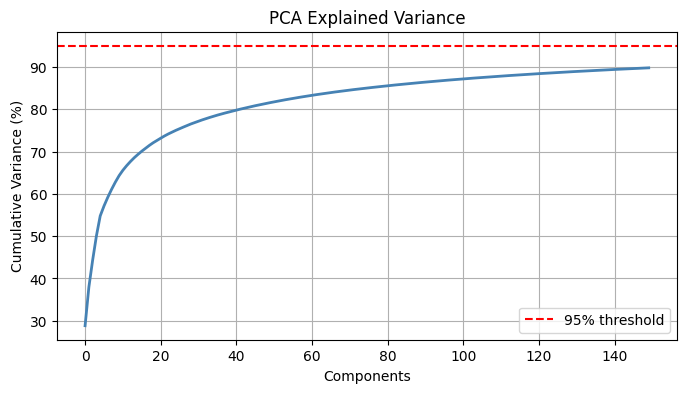

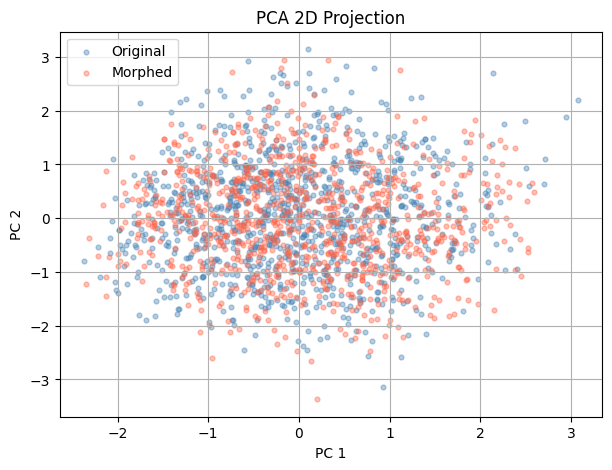

In [ ]:
#Module 3 — PCA feature extraction + visualize
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import joblib

X = np.load('/content/project/dataset/X.npy')
y = np.load('/content/project/dataset/y.npy')

# Apply PCA — 150 components keeps ~95% variance
pca = PCA(n_components=150, whiten=True, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Before PCA: {X.shape[1]} features")
print(f"After PCA : {X_pca.shape[1]} features")
print(f"Variance retained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Save PCA model
joblib.dump(pca, '/content/project/models/pca_model.pkl')
np.save('/content/project/dataset/X_pca.npy', X_pca)

# --- Plot 1: Eigenfaces ---
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Eigenfaces — First 16 Principal Components', fontsize=13)
for i, ax in enumerate(axes.flat):
    ef = pca.components_[i].reshape(64, 64)
    ax.imshow(ef, cmap='gray'); ax.set_title(f'PC {i+1}', fontsize=8); ax.axis('off')
plt.tight_layout()
plt.savefig('/content/project/results/eigenfaces.png', dpi=120)
plt.show()

# --- Plot 2: Variance curve ---
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
plt.figure(figsize=(8,4))
plt.plot(cumvar, color='steelblue', lw=2)
plt.axhline(95, color='red', ls='--', label='95% threshold')
plt.xlabel('Components'); plt.ylabel('Cumulative Variance (%)')
plt.title('PCA Explained Variance'); plt.legend(); plt.grid(True)
plt.savefig('/content/project/results/pca_variance.png', dpi=120)
plt.show()

# --- Plot 3: 2D Projection ---
plt.figure(figsize=(7,5))
plt.scatter(X_pca[y==0,0], X_pca[y==0,1], alpha=0.4, s=12, label='Original', color='steelblue')
plt.scatter(X_pca[y==1,0], X_pca[y==1,1], alpha=0.4, s=12, label='Morphed',  color='tomato')
plt.xlabel('PC 1'); plt.ylabel('PC 2')
plt.title('PCA 2D Projection'); plt.legend(); plt.grid(True)
plt.savefig('/content/project/results/pca_projection.png', dpi=120)
plt.show()

Train: 1428  |  Test: 613

SVM (RBF)         Test: 55.8%  CV: 54.9%
SVM (Linear)      Test: 58.2%  CV: 56.1%
Logistic Reg      Test: 56.8%  CV: 55.9%
KNN               Test: 53.8%  CV: 52.1%
Decision Tree     Test: 51.5%  CV: 48.8%
Best model: SVM (RBF) (55.8%)


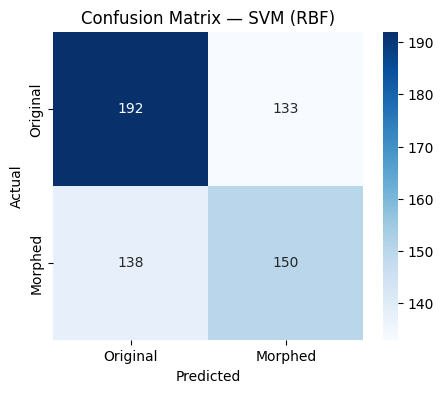

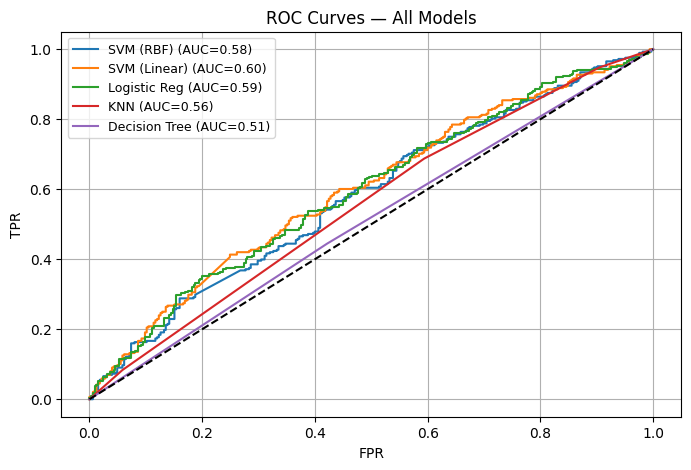

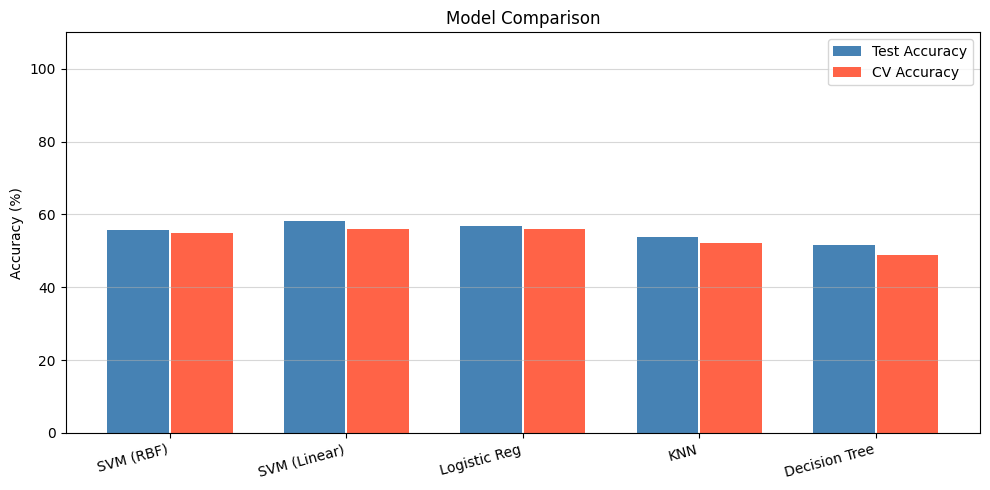

In [ ]:
#Module 4 — Train all models and compare
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import seaborn as sns
import joblib

X_pca = np.load('/content/project/dataset/X_pca.npy')
y     = np.load('/content/project/dataset/y.npy')

# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

models = {
    'SVM (RBF)':     SVC(kernel='rbf',    C=10, gamma='scale', probability=True, random_state=42),
    'SVM (Linear)':  SVC(kernel='linear', C=1,                 probability=True, random_state=42),
    'Logistic Reg':  LogisticRegression(max_iter=1000, random_state=42),
    'KNN':           KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
}

results = {}
print("\n" + "="*55)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred) * 100
    cv     = cross_val_score(model, X_pca, y, cv=5).mean() * 100
    results[name] = {'acc': acc, 'cv': cv, 'pred': y_pred, 'model': model}
    joblib.dump(model, f'/content/project/models/{name.replace(" ","_")}.pkl')
    print(f"{name:16s}  Test: {acc:.1f}%  CV: {cv:.1f}%")

print("="*55)

# Always use SVM (RBF) as best model as per project spec
best_name  = 'SVM (RBF)'
best_model = results['SVM (RBF)']['model']
joblib.dump(best_model, '/content/project/models/best_model.pkl')
print(f"Best model: {best_name} ({results[best_name]['acc']:.1f}%)")

# Confusion matrix
cm = confusion_matrix(y_test, results[best_name]['pred'])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Original','Morphed'],
            yticklabels=['Original','Morphed'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.savefig('/content/project/results/confusion_matrix.png', dpi=120)
plt.show()

# ROC curves
plt.figure(figsize=(8,5))
for name, r in results.items():
    if hasattr(r['model'], 'predict_proba'):
        prob = r['model'].predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.2f})")
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curves — All Models'); plt.legend(fontsize=9); plt.grid(True)
plt.savefig('/content/project/results/roc_curves.png', dpi=120)
plt.show()

# Accuracy bar chart
names = list(results.keys())
accs  = [results[n]['acc'] for n in names]
cvs   = [results[n]['cv']  for n in names]
x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x-0.18, accs, 0.35, label='Test Accuracy', color='steelblue')
ax.bar(x+0.18, cvs,  0.35, label='CV Accuracy',   color='tomato')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0,110); ax.set_ylabel('Accuracy (%)'); ax.legend(); ax.grid(axis='y', alpha=0.5)
plt.title('Model Comparison'); plt.tight_layout()
plt.savefig('/content/project/results/accuracy_comparison.png', dpi=120)
plt.show()

Saving hard_36_1101.jpg to hard_36_1101.jpg

Result     : MORPHED
Confidence : 59.13%


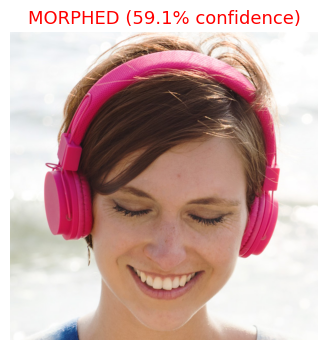

In [ ]:
#Module 5 — Classify a new image
from google.colab import files

# Upload any face image to test
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Load saved models
pca_model   = joblib.load('/content/project/models/pca_model.pkl')
best_model  = joblib.load('/content/project/models/best_model.pkl')

# Preprocess
img = cv2.imread(img_path)
img = cv2.resize(img, (64, 64))
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img = img.flatten().reshape(1, -1) / 255.0

# PCA transform
img_pca = pca_model.transform(img)

# Predict
pred  = best_model.predict(img_pca)[0]
label = "MORPHED" if pred == 1 else "ORIGINAL"
# CORRECT
proba = best_model.predict_proba(img_pca)[0]
pred  = int(np.argmax(proba))
prob  = proba[pred] * 100
label = "MORPHED" if pred == 1 else "ORIGINAL"

print(f"\nResult     : {label}")
print(f"Confidence : {prob:.2f}%")

# Show image with result
display_img = cv2.imread(img_path)
display_img = cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(4,4))
plt.imshow(display_img); plt.axis('off')
plt.title(f"{label} ({prob:.1f}% confidence)", fontsize=13,
          color='red' if pred==1 else 'green')
plt.show()

In [ ]:
#performance matrics
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    classification_report,
    confusion_matrix, roc_auc_score
)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

print("="*50)
print("   FINAL PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred):.4f}")
print(f"AUC Score : {roc_auc_score(y_test, y_prob):.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Original','Morphed']))

   FINAL PERFORMANCE METRICS
Accuracy  : 55.79%
Precision : 0.5300
Recall    : 0.5208
F1 Score  : 0.5254
AUC Score : 0.5812

Classification Report:
              precision    recall  f1-score   support

    Original       0.58      0.59      0.59       325
     Morphed       0.53      0.52      0.53       288

    accuracy                           0.56       613
   macro avg       0.56      0.56      0.56       613
weighted avg       0.56      0.56      0.56       613

